# 数据处理

In [1]:
from pathlib import Path

import numpy as np
import ml_from_scratch.data.data_processor as data_processor

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# 从源文件中读取数据
root_path = Path.cwd().parents[1]
data_file = Path("data/raw/logistic_classification/lr_dataset.csv")

lines = data_processor.load_csv(root_path / data_file)

X_total = lines[:, 0:2]
y_total = lines[:, 2].reshape(-1,1)
print("数据集大小：", len(X_total))

数据集大小： 1000


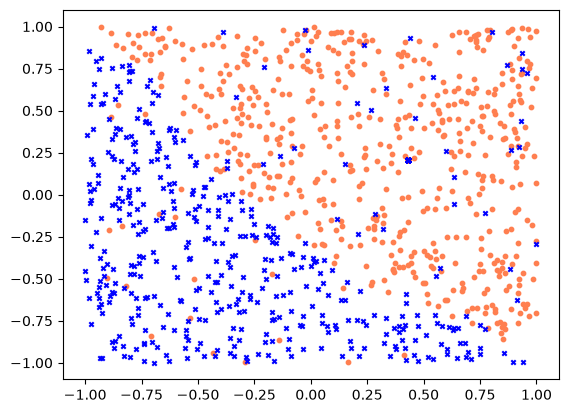

In [3]:
# 将点数据绘制在二维平面上
pos_index = np.where(y_total == 1)
neg_index = np.where(y_total == 0)

fig,ax = plt.subplots(1)
ax.scatter(X_total[pos_index, 0], X_total[pos_index, 1], marker='o', color="coral", s=10)
ax.scatter(X_total[neg_index, 0], X_total[neg_index, 1], marker='x', color="blue", s=10)

plt.show()
plt.close()

In [4]:
# 划分数据集与验证集
X_train, X_valid, y_train, y_valid = data_processor.train_test_split(X=X_total, y=y_total,train_ratio=0.7, seed=42)

# 在数据矩阵上拼接常数项
X_train = data_processor.cat_constant(X_train)
X_valid = data_processor.cat_constant(X_valid)
## 检查数据
print(
    X_total.shape, X_train.shape, X_valid.shape, X_train,
    sep="\n"
)

(1000, 2)
(700, 3)
(300, 3)
[[ 1.      0.9964 -0.4046]
 [ 1.      0.7304  0.9101]
 [ 1.      0.5951  0.6161]
 ...
 [ 1.      0.5425 -0.9757]
 [ 1.     -0.9509 -0.2233]
 [ 1.     -0.8046  0.0298]]


# 模型训练

In [5]:
import ml_from_scratch.classification.logistic_classifier as classifier

In [6]:
# 参数设定
num_steps = 250
learning_rate = 2e-3
l2_coef = 1.0

In [7]:
# 构建一个分类器并加载数据
## 定义分类器
myClassifier = classifier.LogisticClassifier(lr=learning_rate, l2_coef=l2_coef)
## 给分类器加载数据
myClassifier.load_train_and_valid(X_train=X_train, y_train=y_train, X_valid=X_valid, y_valid=y_valid)
## 分类器在数据上进行训练，记录训练结果
train_losses, valid_losses, train_acc, valid_acc, train_auc, valid_auc = myClassifier.GD(num_steps=num_steps)
## 输出预测结果
y_proba_valid = myClassifier.predict_proba(X_valid)
y_pred_valid = myClassifier.predict(X_valid, threshold=0.5)

# 模型评估

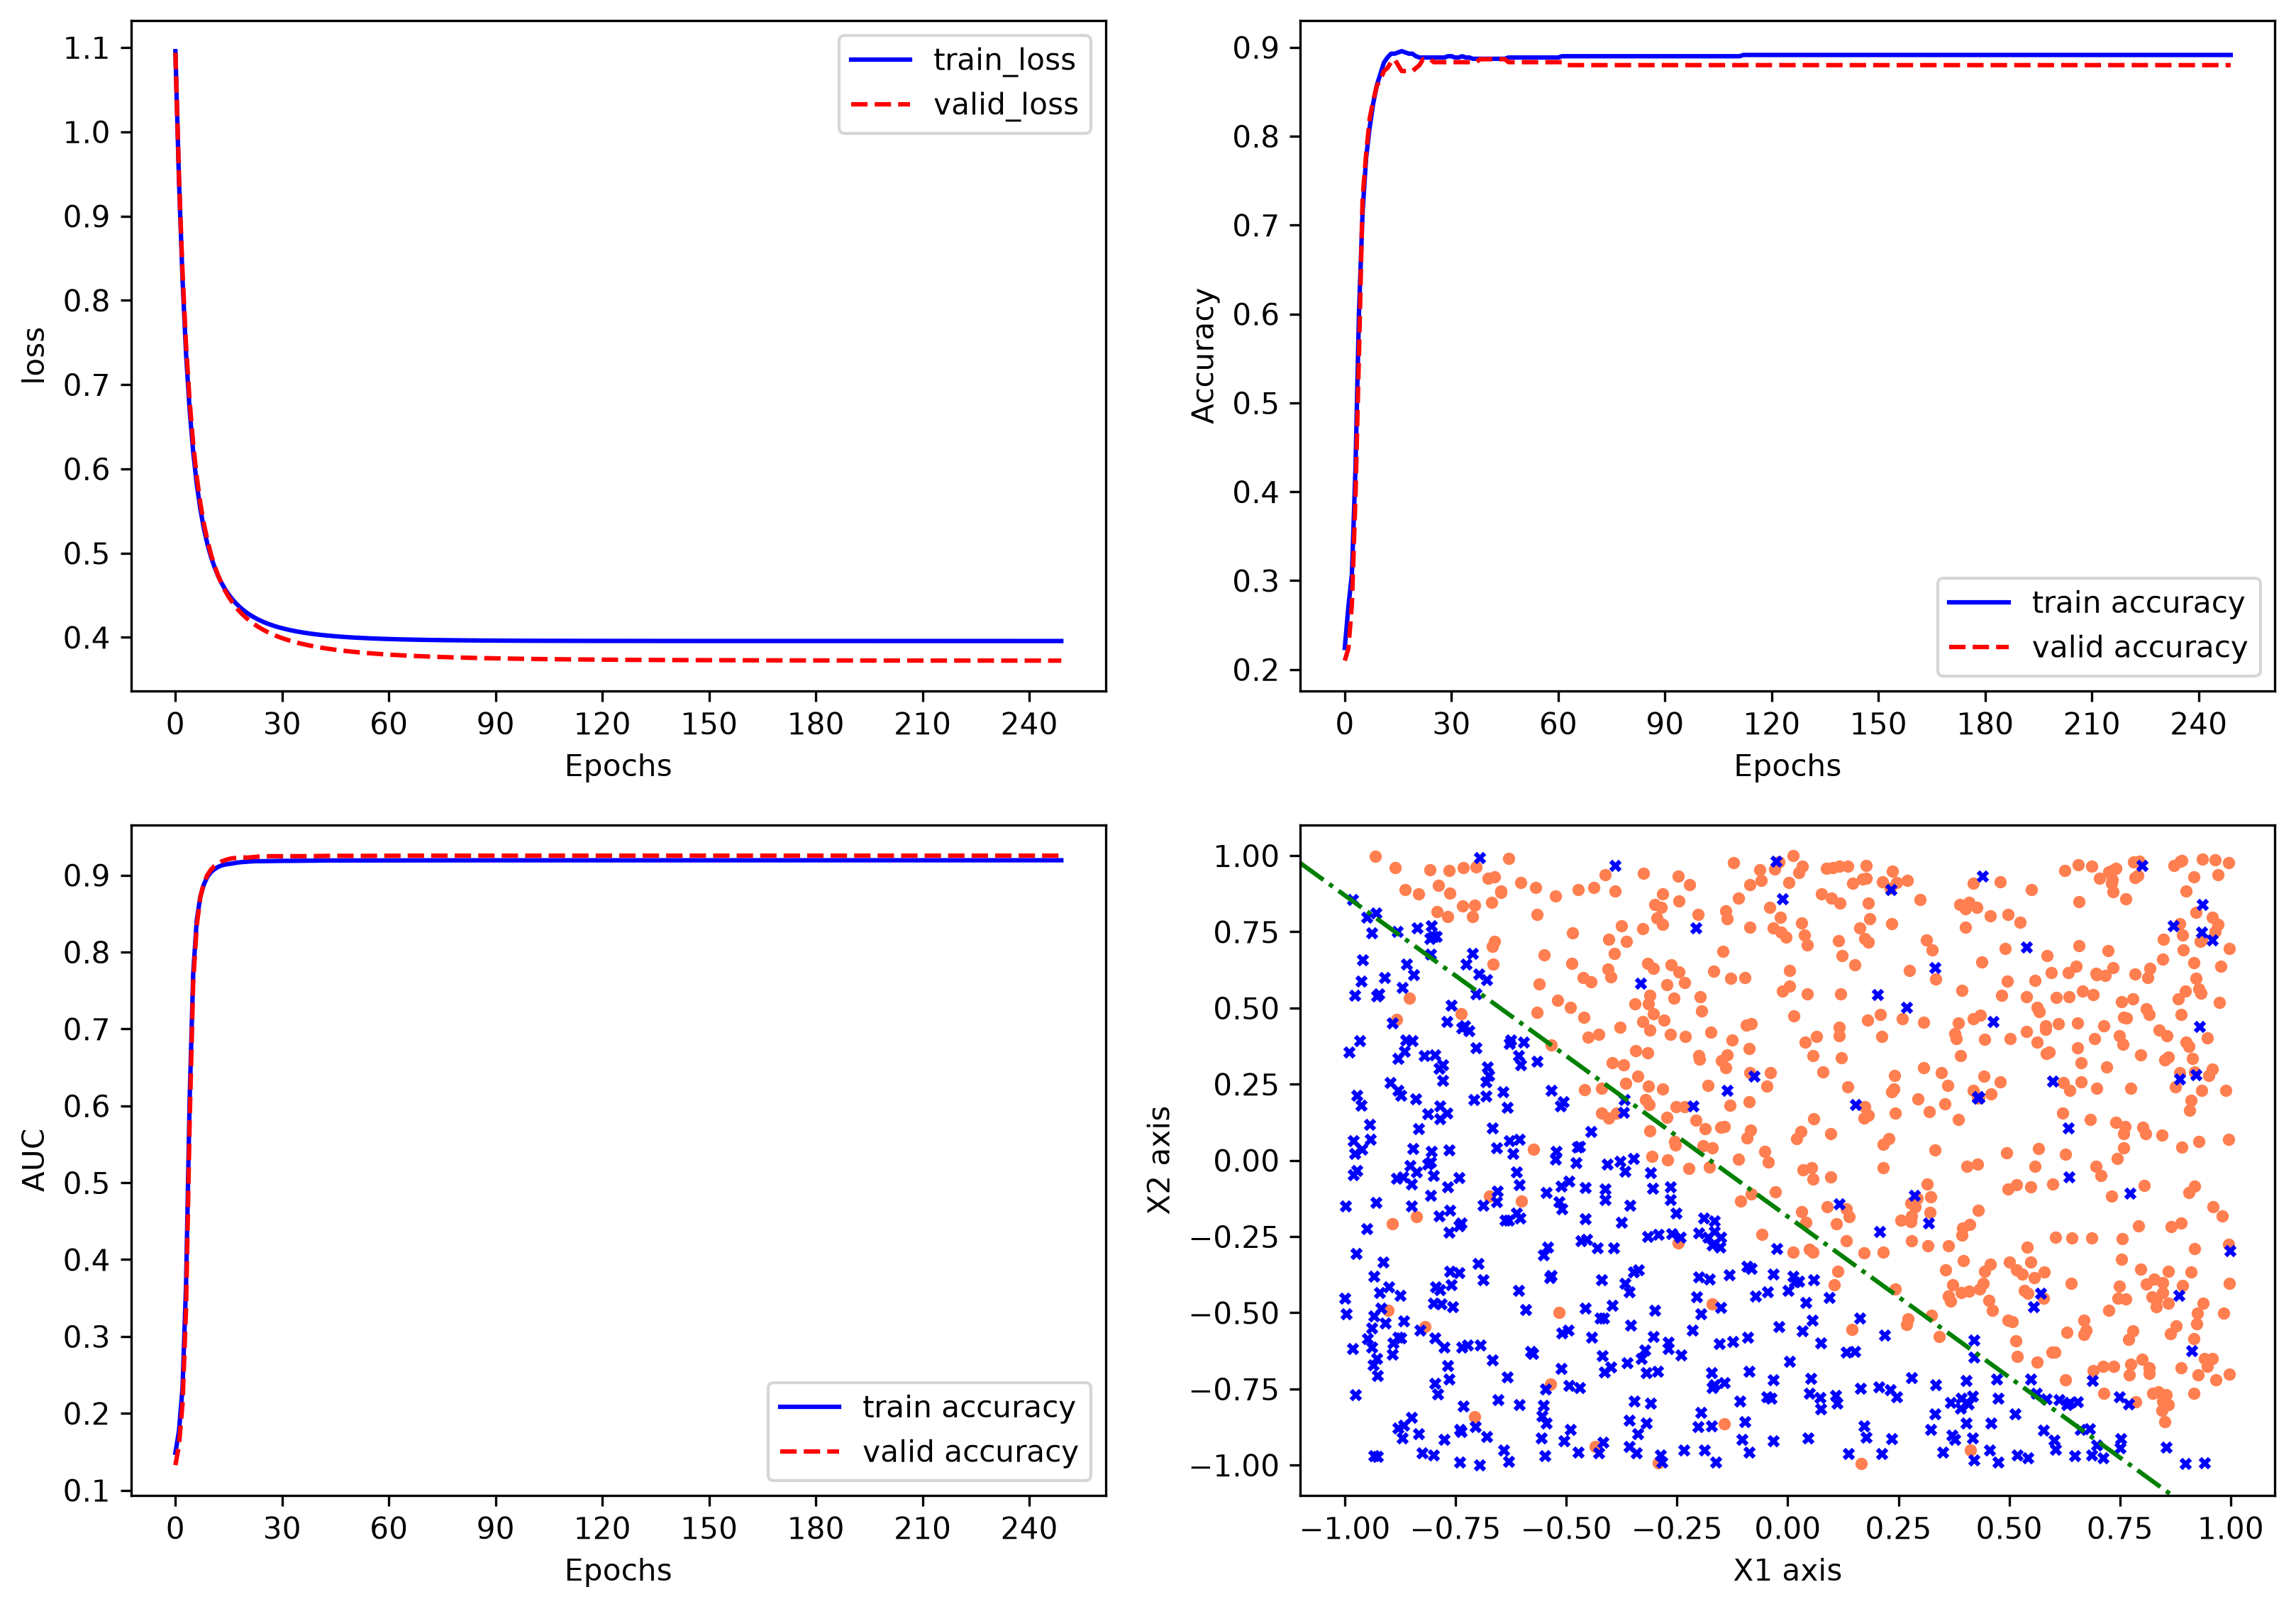

In [33]:
# 将训练的结果绘制出来
plt.figure(figsize=(13,9), dpi=300)
x_ticks = np.arange(num_steps)

## 绘制损失曲线
plt.subplot(2,2,1)
plt.plot(x_ticks, train_losses, color="blue", label="train_loss")
plt.plot(x_ticks, valid_losses, color="red", ls="--" ,label="valid_loss")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()

## 绘制准确率曲线
plt.subplot(2,2,2)
plt.plot(x_ticks, train_acc, color="blue", label="train accuracy")
plt.plot(x_ticks, valid_acc, color="red", ls="--", label="valid accuracy")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

## 绘制AUC曲线
plt.subplot(2,2,3)
plt.plot(x_ticks, train_auc, color="blue", label="train accuracy")
plt.plot(x_ticks, valid_auc, color="red", ls="--", label="valid accuracy")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()

## 绘制模型学到的分割直线(阈值为0.5)
plt.subplot(2,2,4)
theta = myClassifier.theta
plot_x = np.linspace(-1.1, 1.1, 100)
plot_y = -(theta[1]*plot_x + theta[0]) / theta[2]
pos_index = np.where(y_total == 1)
neg_index = np.where(y_total == 0)

plt.scatter(X_total[pos_index, 0], X_total[pos_index, 1], marker='o', color="coral", s=10)
plt.scatter(X_total[neg_index, 0], X_total[neg_index, 1], marker='x', color="blue", s=10)
plt.plot(plot_x, plot_y, ls="-.", color="green")

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("X1 axis")
plt.ylabel("X2 axis")

plt.show()
plt.close()

250